In [220]:
#########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)              #
# E-mail: wgomez@cinvestav.mx                           #
# Curso:   Análisis de datos                            #
# Tópico:  Regresión logística                          #
#########################################################

Carga bibliotecas necesarias

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [222]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Selecciona entre caso binario o multiclase

In [223]:
opt = 0 # 0 para caso multiclase y 1 para caso binario
labels = iris.target_names  # Etiquetas de clase
if opt:
  idx = (Y == 1) | (Y == 2) # Selecciona clases versicolor y virginica
  X = X[idx.ravel(), :]
  Y = Y[idx.ravel(), :]
  Y = (Y==np.max(Y, axis=0)).astype(float)  # Asegura etiquetas 0 y 1
  labels = iris.target_names[[1,2]] # Etiquetas de clase

Divide el conjunto de datos en 80\% para entrenamiento y 20\% para prueba

In [224]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Normaliza el conjunto de datos con z-score:  $z = \frac{x-\mu}{\sigma}$

In [225]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Normaliza el conjunto de entrenamiento
X_test = scaler.transform(X_test) # Normaliza el conjunto de prueba usando los estadísticos del conjunto de entrenamiento

Funciones para entrenar un modelo de regresión logística

In [226]:
# Función principal de entrenamiento
def LRtrain(X, Y, eta, tmax):
    c = np.unique(Y)
    nc = len(c)
    n = X.shape[0]
    X = np.hstack((np.ones((n, 1)), X))  # Vectores aumentados
    if nc > 2:
        T = np.zeros((n, nc))
        for i in range(nc):
            T[Y == c[i], i] = 1  # One-hot encoding
        W, L = trainMclass(X, T, eta, tmax)  # Caso multiclase
    else:
        W, L = train2class(X, Y, eta, tmax)  # Caso binario
    return W, L

# Función para entrenar modelo para caso binario
def train2class(X, T, eta, tmax):
    d = X.shape[1]  # Número de características
    W = np.zeros(d)  # Vector de pesos
    loss = np.zeros(tmax)
    for t in range(tmax):  # Ciclo de descenso de gradiente
        P = 1 / (1 + np.exp(-X @ W))  # Función sigmoide
        W -= eta * (P - T) @ X  # Actualiza pesos
        loss[t] = -np.mean(T * np.log(P) + (1 - T) * np.log(1 - P))  # Entropía cruzada binaria
    return W, loss

# Función para entrenar para caso multiclase
def trainMclass(X, T, eta, tmax):
    d = X.shape[1]  # Número de características
    c = T.shape[1]  # Número de clases
    W = np.zeros((c, d))  # Matriz de pesos
    loss = np.zeros(tmax)
    for t in range(tmax):  # Ciclo de descenso de gradiente
        E = np.exp(X @ W.T)
        P = E / np.sum(E, axis=1, keepdims=True)  # Función softmax
        W -= eta * (P - T).T @ X  # Actualiza pesos
        loss[t] = -np.mean(T * np.log(P))  # Entropía cruzada categórica
    return W, loss

# Función para predecir con el modelo
def LRpredict(X, W):
    n = X.shape[0]
    X = np.hstack((np.ones((n, 1)), X))  # Vectores aumnetados
    if W.ndim > 1:
        E = np.exp(X @ W.T)
        Pr = E / np.sum(E, axis=1, keepdims=True)  # Softmax
        Ypp = np.argmax(Pr, axis=1)  # Clasifica por máxima probabilidad
    else:
        Pr = 1 / (1 + np.exp(-X @ W))  # Sigmoide
        Ypp = (Pr > 0.5).astype(float)  # Clasifica con umbral en 0.5
    Ypp = Ypp.reshape(-1, 1) # Asegurar vector columna
    return Ypp

Entrena y clasifica con el modelo de regresión logística

In [227]:
eta = 1e-3  # Tasa de aprendizaje
tmax = 2000 # Número de iteraciones
W, L = LRtrain(X_train, Y_train.ravel(), eta, tmax) # Entrenamiento
Y_pred = LRpredict(X_test, W)  # Clasificación
print(f"Vectores de pesos:\n {W}")

Vectores de pesos:
 [[-0.60065174 -1.70566553  1.54881321 -2.76633548 -2.59389306]
 [ 2.97785263  0.95785683 -0.42621621 -0.27337298 -1.36323922]
 [-2.37720089  0.74780869 -1.122597    3.03970846  3.95713228]]


Visualiza matriz de confusión

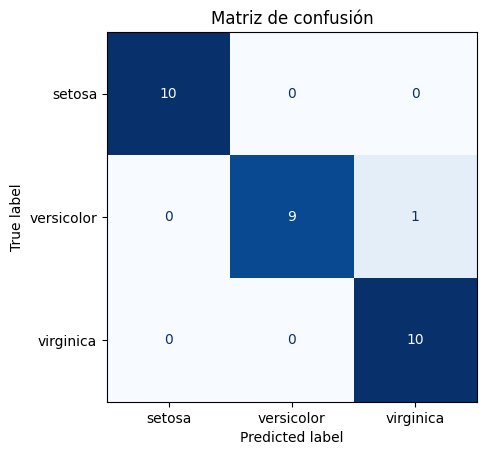

Exactitud: 0.967


In [228]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()
ACC = np.mean(Y_pred == Y_test)
print(f"Exactitud: {ACC:.3f}")

Grafica la curva de aprendizaje

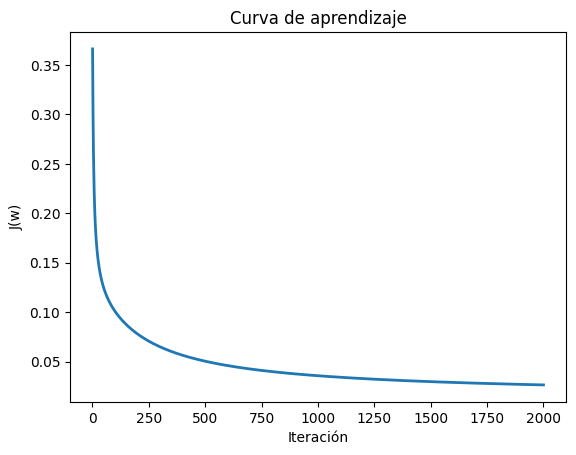

In [229]:
plt.figure(facecolor='w')
plt.plot(range(1, tmax + 1), L, linewidth=2)
plt.xlabel('Iteración')
plt.ylabel('J(w)')
plt.title('Curva de aprendizaje')
plt.show()